In [1]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.ticker import ScalarFormatter
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import matplotlib as mpl

In [2]:
plt.rcParams.update({'axes.linewidth' : 1.5, 
                     'ytick.major.width' : 1.5,
                     'ytick.minor.width' : 1.5,
                     'xtick.major.width' : 1.5,
                     'xtick.minor.width' : 1.5,
                     'xtick.labelsize': 12, 
                     'ytick.labelsize': 12,
                     'axes.labelsize': 18,
                     'axes.labelpad' : 5,
                     'axes.titlesize' : 24,
                     'axes.titlepad' : 10,
                     'font.family': 'Serif'
                    })

#for poster
# plt.rcParams.update({'axes.linewidth' : 1.5, 
#                      'ytick.major.width' : 1.5,
#                      'ytick.minor.width' : 1.5,
#                      'xtick.major.width' : 1.5,
#                      'xtick.minor.width' : 1.5,
#                      'xtick.labelsize': 14, 
#                      'ytick.labelsize': 14,
#                      'axes.labelsize': 24,
#                      'axes.labelpad' : 5,
#                      'axes.titlesize' : 36,
#                      'axes.titlepad' : 10,
#                      'font.family': 'Serif'
#                     })

mpl.rcParams['mathtext.fontset'] = 'cm'          # Computer Modern serif
mpl.rcParams['mathtext.rm'] = 'serif'

In [4]:
# load in data
root = "/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/"

## intitialize the list of sectors 
planet_sectors = ["u42", "u43", "u44", "n42", "n70"]

light_curves = []
periodograms = []

for sector in planet_sectors:
    light_curves.append(np.load(root + f"light_curves/{sector}_lcs.npz"))
    periodograms.append(np.load(root + f"periodograms/{sector}_periodogram.npz"))

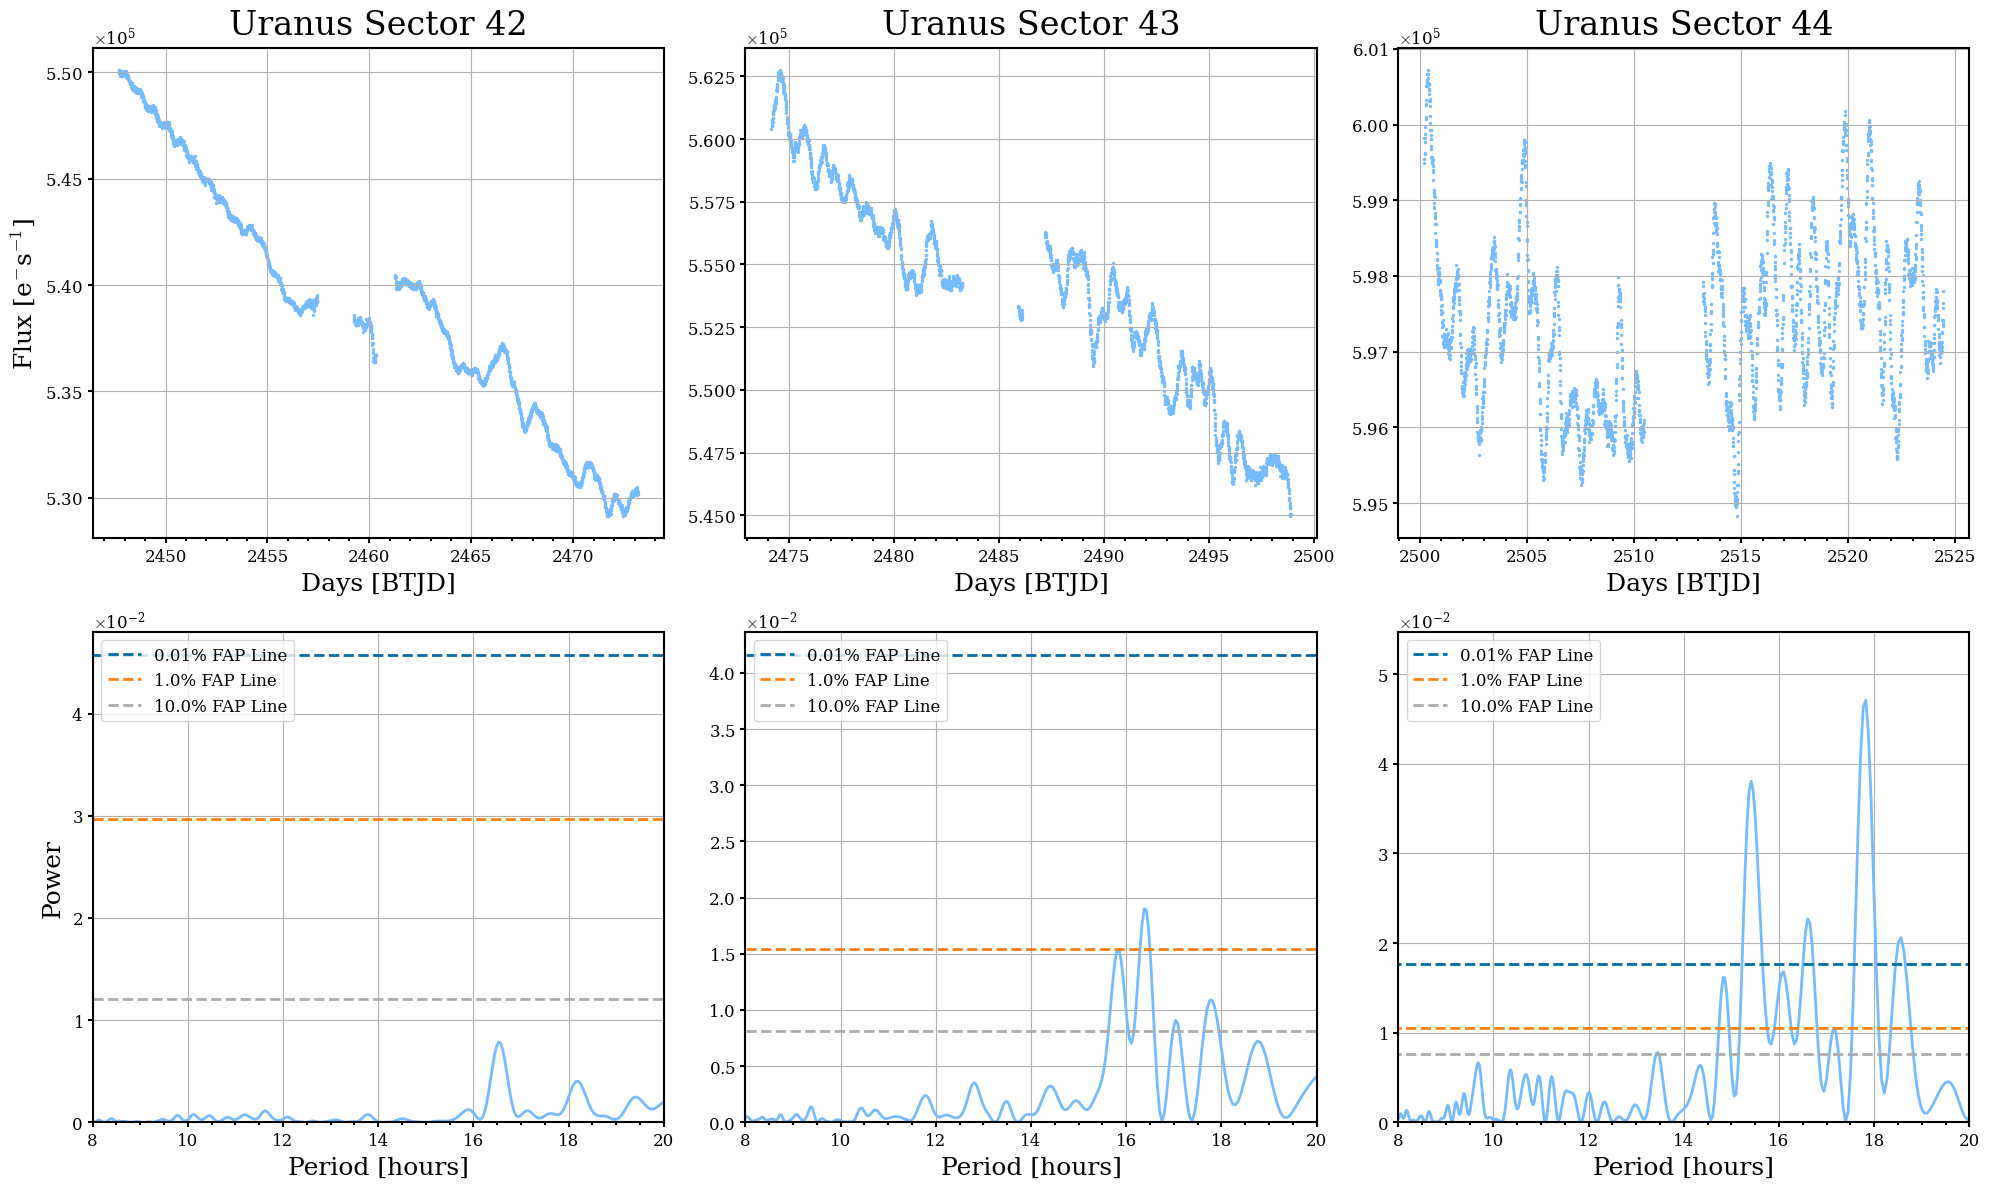

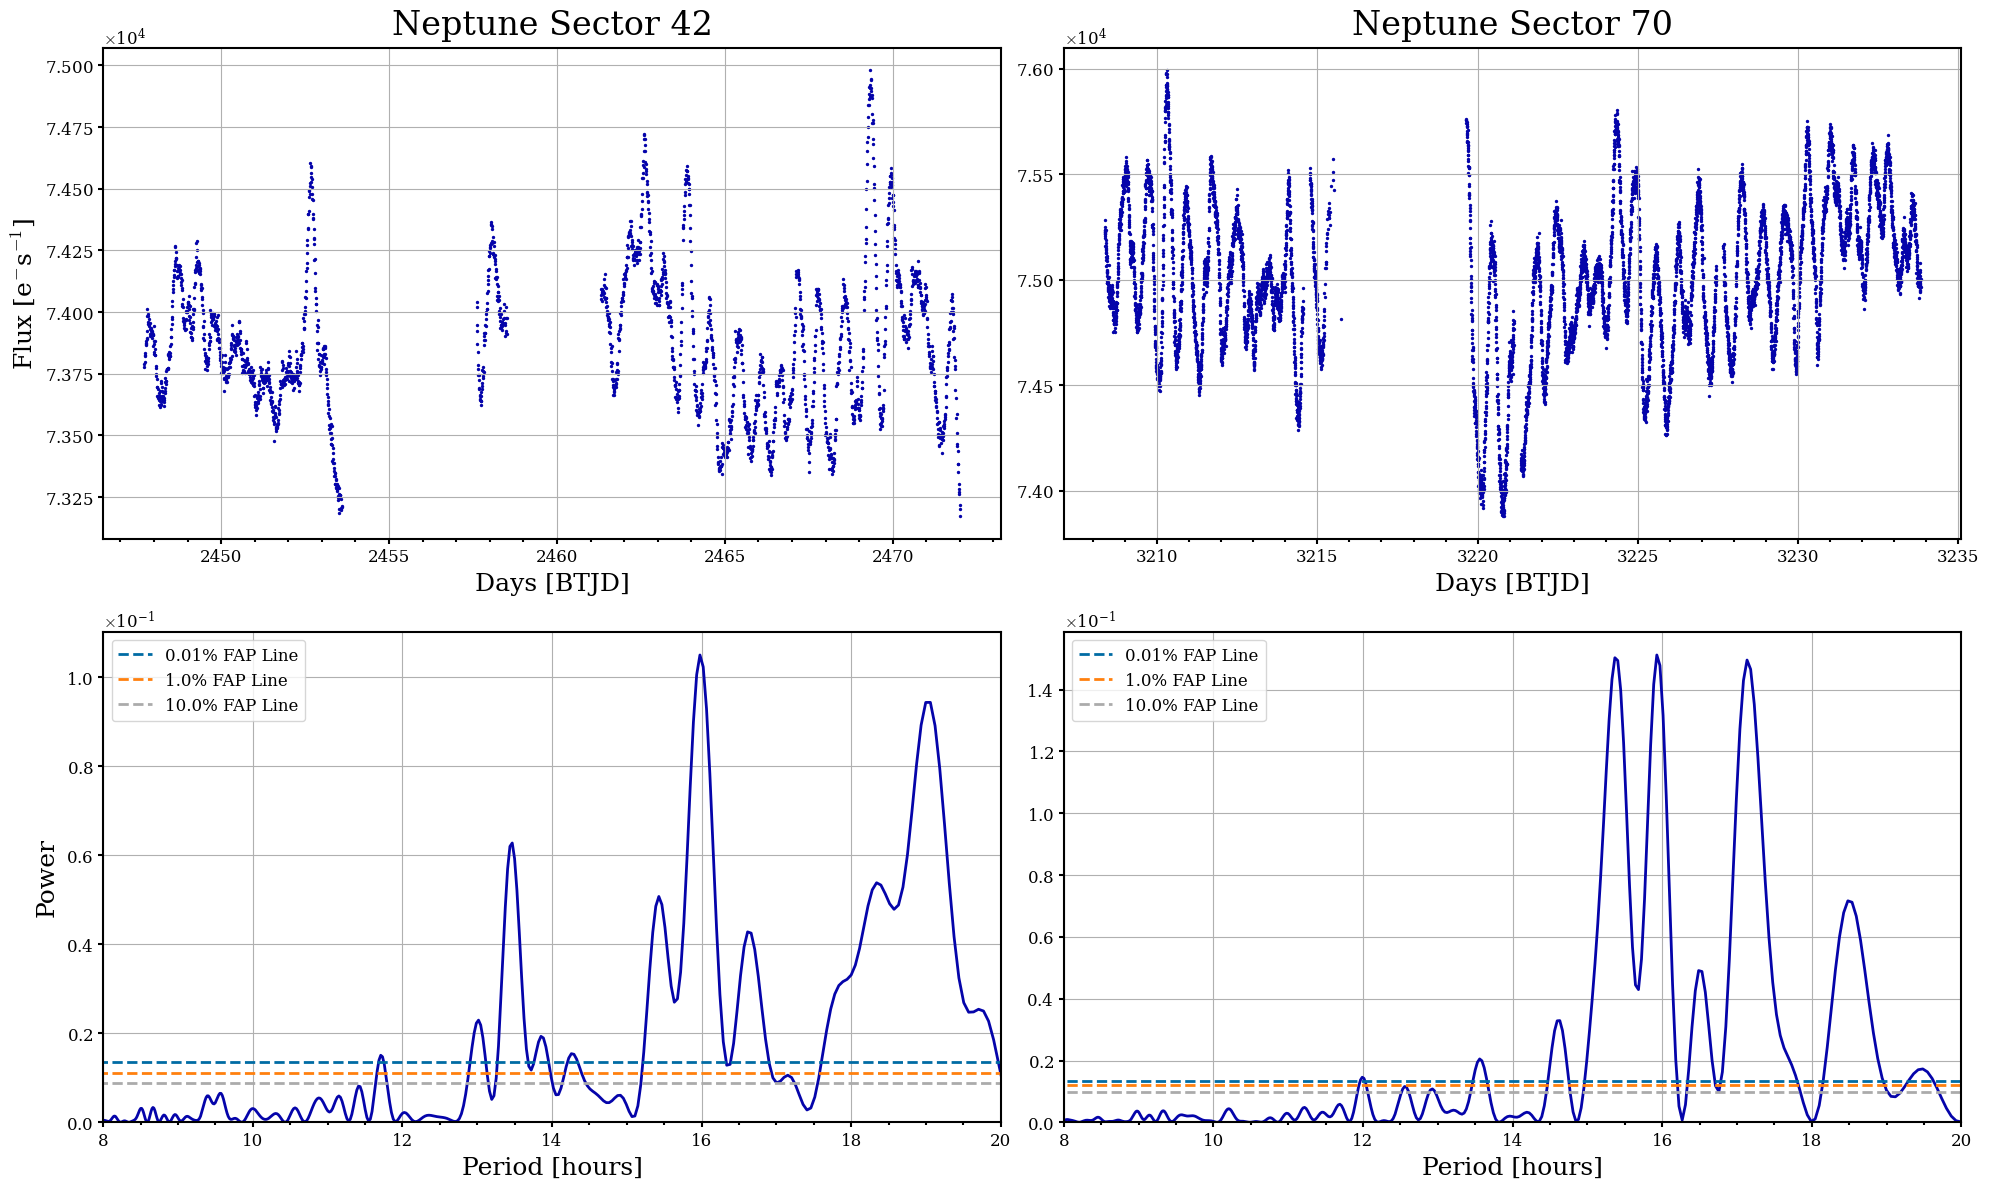

In [ ]:
from figures import plot_lightcurve_and_periodogram

plot_lightcurve_and_periodogram("Uranus", light_curves[0:3], periodograms[0:3], sector_list=[42, 43, 44])
plot_lightcurve_and_periodogram("Neptune", light_curves[3:5], periodograms[3:5], sector_list=[42, 70])

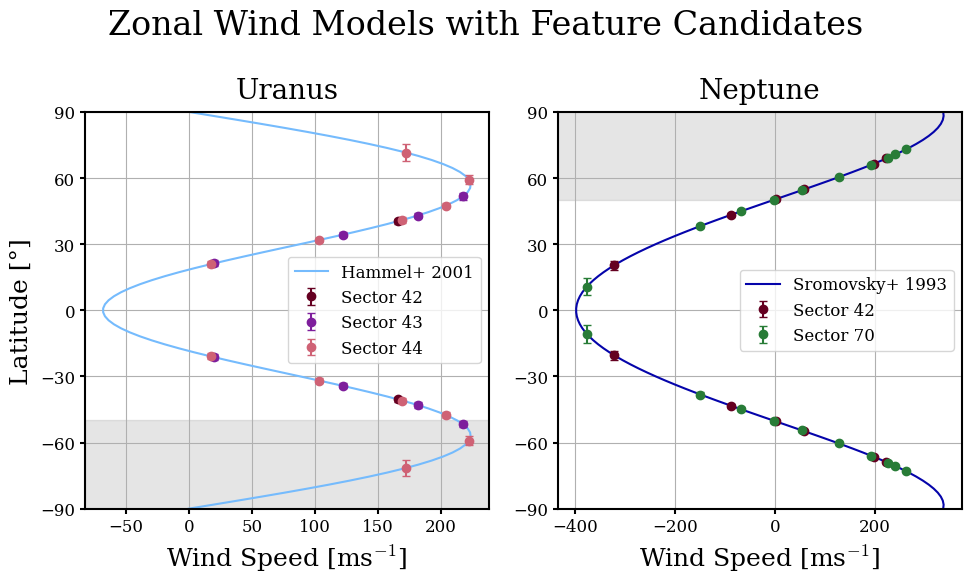

In [12]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def plot_wind(axs):
    axs.grid(True)
    axs.set_yticks(np.arange(-90, 91, 30))
    axs.set_xlabel("Wind Speed [ms$^{-1}$]")
    axs.set_ylim(-90, 90)
    axs.legend(fontsize=12)

phi = np.linspace(-np.pi / 2, np.pi / 2, 100)

# Create the figure
fig = plt.figure(figsize=(10, 6))

fig.suptitle("Zonal Wind Models with Feature Candidates", fontsize=24)

# Define a 2-row, 3-column grid
gs = gridspec.GridSpec(1, 6)

# Top row: 3 equal-width panels
ax1 = fig.add_subplot(gs[0, 0:3])
ax1.set_title("Uranus")
ax1.set_ylabel("Latitude [\u00B0]")
ax1.plot(hammel_wind_speed(phi), np.degrees(phi), color='xkcd:sky blue', label="Hammel+ 2001")
ax1.axhspan(ymin=-150, ymax=-50, color='gray', alpha=0.2)

for i, latitude in enumerate(u42_solutions):
    label = "Sector 42" if i == 0 else None
    ax1.errorbar(u42_wind_speed[i], latitude, yerr=u42_stdev[i], fmt='o', color='xkcd:maroon', capsize=3, label=label)
    ax1.errorbar(u42_wind_speed[i], -latitude, yerr=u42_stdev[i], fmt='o', color='xkcd:maroon', capsize=3)

for i, latitude in enumerate(u43_solutions):
    label = "Sector 43" if i == 0 else None
    ax1.errorbar(u43_wind_speed[i], latitude, yerr=u43_stdev[i], fmt='o', color='xkcd:purple', capsize=3, label=label)
    ax1.errorbar(u43_wind_speed[i], -latitude, yerr=u43_stdev[i], fmt='o', color='xkcd:purple', capsize=3)

for i, latitude in enumerate(u44_solutions):
    label = "Sector 44" if i == 0 else None
    ax1.errorbar(u44_wind_speed[i], latitude, yerr=u44_stdev[i], fmt='o', color='xkcd:rose', capsize=3, label=label)
    ax1.errorbar(u44_wind_speed[i], -latitude, yerr=u44_stdev[i], fmt='o', color='xkcd:rose', capsize=3)

plot_wind(ax1)

ax2 = fig.add_subplot(gs[0, 3:6])
ax2.set_title("Neptune")
ax2.plot(sromovsky_wind(phi), np.degrees(phi), color='xkcd:royal blue', label="Sromovsky+ 1993")
ax2.axhspan(ymin=50, ymax=150, color='gray', alpha=0.2)

for i, latitude in enumerate(n42_solutions):
    label = "Sector 42" if i == 0 else None
    ax2.errorbar(n42_wind_speed[i], latitude, yerr=n42_stdev[i], fmt='o', color='xkcd:maroon', capsize=3, label=label)
    ax2.errorbar(n42_wind_speed[i], -latitude, yerr=n42_stdev[i], fmt='o', color='xkcd:maroon', capsize=3)

for i, latitude in enumerate(n70_solutions):
    label = "Sector 70" if i == 0 else None
    ax2.errorbar(n70_wind_speed[i], latitude, yerr=n70_stdev[i], fmt='o', color='xkcd:darkish green', capsize=3, label=label)
    ax2.errorbar(n70_wind_speed[i], -latitude, yerr=n70_stdev[i], fmt='o', color='xkcd:darkish green', capsize=3)

plot_wind(ax2)

plt.tight_layout()
plt.savefig(directory + "poster_wind", dpi=1000)


In [6]:
def write_solutions(arrs, sectors, i):
    first_period = np.round(24 / arrs[i].item()['all_peaks'][0][0], decimals=2)
    print(f"{sectors[i]} & {first_period}", end=" ")

    for k in range(len(arrs[i].item()['all_lat'])):
        lat = arrs[i].item()['all_lat'][k][0][0]
        std = arrs[i].item()['all_std'][k][0][0]
        print(f"& {np.round(lat, decimals=2)} ± {np.round(std, decimals=2)}", end=" ")
    
    print("\\\\")

    if len(arrs[i].item()['all_peaks'][0]) > 1:
        for j, peak in enumerate(arrs[i].item()['all_peaks'][0][1:]):
            period = 24 / peak
            print(f"& {np.round(period, decimals=2)} ", end=" ")

            for k in range(len(arrs[i].item()['all_lat'])):
                try:
                    lat = arrs[i].item()['all_lat'][k][0][j + 1]
                    std = arrs[i].item()['all_std'][k][0][j + 1]
                    print(f"& {np.round(lat, decimals=2)} ± {np.round(std, decimals=2)}", end=" ")
                except IndexError:
                    print("& -- ", end=" ")
            
            print("\\\\")        


In [45]:
sectors = ['42', '43', '44', '42', '70']

print("Sector & Period (hours) & K98_N & K98_S & H01 & S12E & S12E+O_N & S12E+O_S & FAP \\\\")
for i, arr in enumerate(arrs):

    if i == 3:
        print("Sector & Period (hours) & S93_4 & S93_6 & T2013 & T2014 & FAP \\\\")

    write_solutions(arrs, sectors, i)
    print("\hline")

Sector & Period (hours) & K98_N & K98_S & H01 & S12E & S12E+O_N & S12E+O_S & FAP \\
42 & 16.53 & [36.86 88.84] ± [1.2  0.86] & [32.45 89.07] ± [1.09 0.7 ] & [30.94 89.12] ± [1.11 0.7 ] & [34.74 88.97] ± [1.05 0.79] & [35.56 88.94] ± [0.95 0.82] & [33.61 88.94] ± [1.19 0.76] \\
\hline
43 & 17.8 & [ 9.83 89.25] ± [3.71 0.57] & [ 6.88 89.32] ± [2.84 0.51] & [22.42 89.19] ± [1.29 0.6 ] & [25.14 89.1 ] ± [1.82 0.65] & [26.97 89.1 ] ± [1.74 0.68] & [23.39 89.12] ± [1.79 0.66] \\
& 17.04  & [28.66 89.05] ± [1.29 0.72] & [89.17 24.59] ± [0.64 1.18] & [88.97 33.35] ± [0.75 1.1 ] & [36.82 88.87] ± [0.95 0.85] & [37.41 88.9 ] ± [0.85 0.84] & [35.93 88.85] ± [1.08 0.83] \\
& 16.38  & [39.29 88.71] ± [1.21 0.92] & [34.73 88.97] ± [1.08 0.77] & [88.75 41.31] ± [0.94 1.14] & [42.7  88.55] ± [0.78 1.06] & [88.57 42.84] ± [1.07 0.74] & [42.71 88.57] ± [0.9  1.07] \\
& 15.85  & [47.66 88.42] ± [1.36 1.19] & [88.74 42.48] ± [0.96 1.14] & --  & --  & --  & --  \\
\hline
44 & 17.82 & [ 8.76 89.26] ± [3.85 

In [9]:
s70_s93_4 = np.load("/home/ktp9/TESSNeptune24/tess-ice-giants/neptune_s42_resampled_mcmc_results_s93_4.npy", allow_pickle=True)
keys = ['all_lat', 'all_std', 'all_peaks']

write_solutions([s70_s93_4], ['42'], 0)

42 & 18.34 & [18.8] ± [2.13] \\
& 17.15  & [38.4] ± [1.03] \\
& 16.62  & [44.24] ± [0.89] \\
& 15.98  & [50.14] ± [0.79] \\
& 15.43  & [54.53] ± [0.71] \\
& 14.26  & [62.28] ± [0.59] \\
& 13.85  & [64.59] ± [0.56] \\
& 13.47  & [66.58] ± [0.53] \\
& 13.02  & [68.74] ± [0.5] \\
& 11.71  & [73.98] ± [0.4] \\
